最新数据日期：2025-12-05


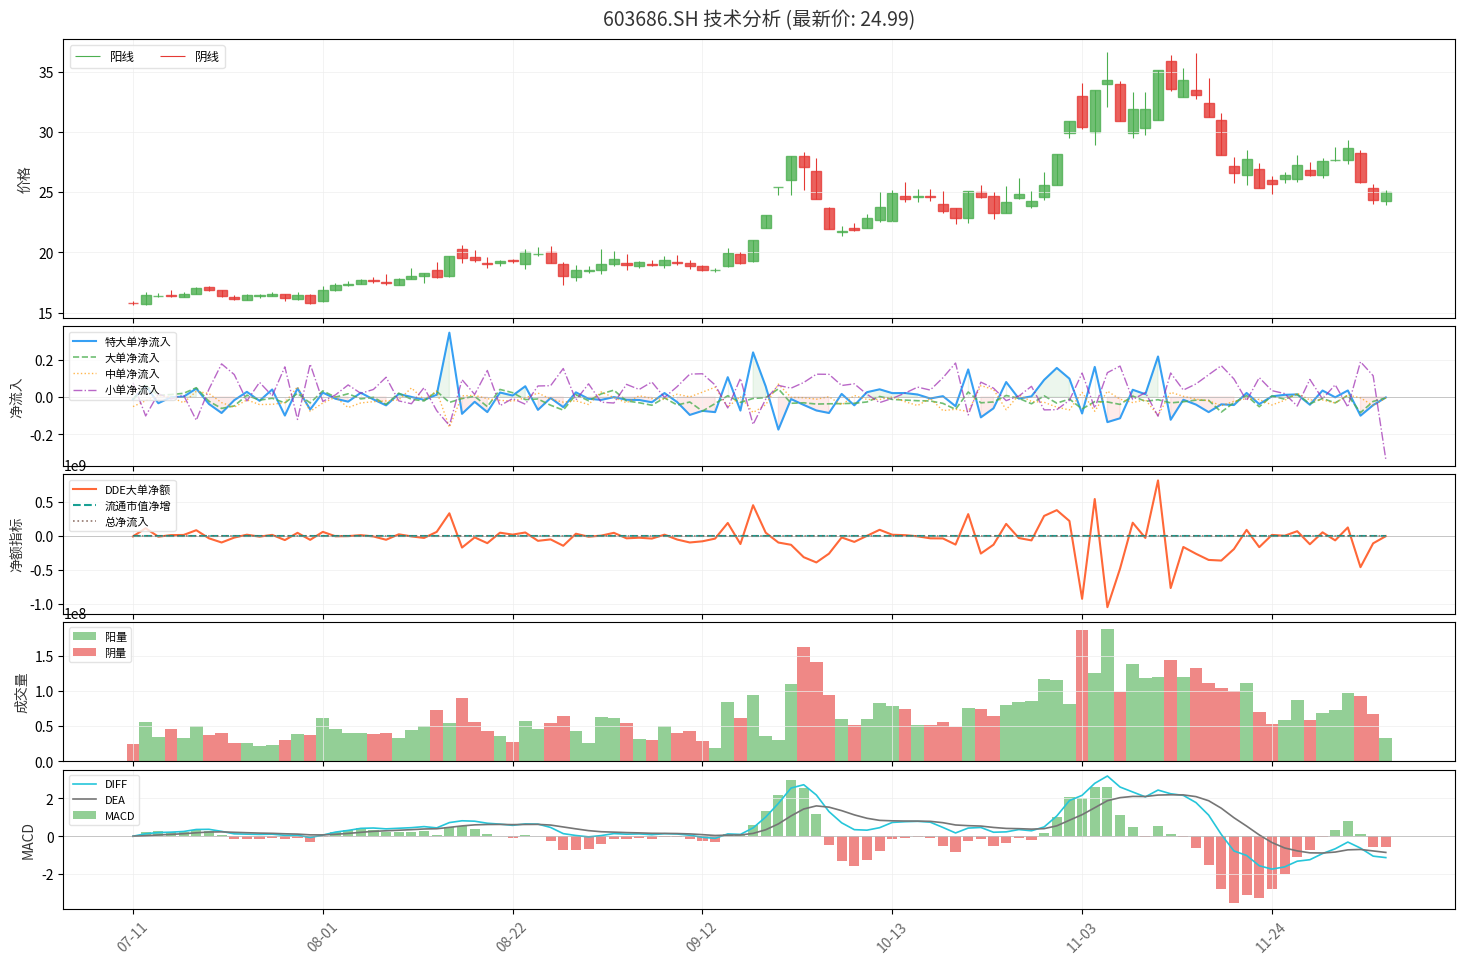

In [11]:
# 完整技术分析看盘程序 v1.0
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib import gridspec
import argparse
import datetime
import numpy as np
from numpy.lib.stride_tricks import sliding_window_view

# ================= 指标计算 =================
def calculate_indicators(df, M=55, N=34, 
                        window_llv=10, window_hhv=25,
                        ema_period=4):
    """集成所有指标计算"""
    # 基础数据准备
    df['LC'] = df['close'].shift(1)
    df['CLOSE_LC'] = df['close'] - df['LC']
    
    # VR指标
    av = df['volume'].where(df['close'] > df['LC'], 0)
    bv = df['volume'].where(df['close'] < df['LC'], 0)
    cv = df['volume'].where(df['close'] == df['LC'], 0)
    df['vr'] = (av.rolling(24).sum() + cv.rolling(24).sum()/2) / \
              (bv.rolling(24).sum() + cv.rolling(24).sum()/2 + 1e-7) * 100
    
    # MACD
    fast_ema = df['close'].ewm(span=5, adjust=False).mean()
    slow_ema = df['close'].ewm(span=13, adjust=False).mean()
    df['diff'] = fast_ema - slow_ema
    df['dea'] = df['diff'].ewm(span=8, adjust=False).mean()
    df['macd'] = 2 * (df['diff'] - df['dea'])
    
    return df.drop(['LC','CLOSE_LC'], axis=1)

# ================= 可视化 =================
def plot_indicators(df, title='技术分析看盘'):
        
    # 定义资金流字段（需要除以turnover的）
    # 注意：buy_l和sell_l实际上是小单的买入和卖出金额
    turnover_normalized_cols = [
        'act_buy_xl', 'pas_buy_xl', 'act_buy_l', 'pas_buy_l',
        'act_buy_m', 'pas_buy_m', 'act_sell_xl', 'pas_sell_xl',
        'act_sell_l', 'pas_sell_l', 'act_sell_m', 'pas_sell_m',
        'buy_l', 'sell_l'  # 注意：这些是小单，不是大单！
    ]
    
    # 检查数据中是否有turnover字段
    if 'turnover' in df.columns:
        # 复制一份数据用于处理，避免修改原始数据
        plot_df = df.copy()
        
        # 对需要除以turnover的列进行处理
        for col in turnover_normalized_cols:
            if col in plot_df.columns:
                plot_df[f'{col}_norm'] = plot_df[col] / (plot_df['turnover'] + 1e-7)
    else:
        plot_df = df.copy()
    
    # 计算每个档位的真实主买和主卖（主买-被卖，主卖-被买）
    # 特大单 (xl)
    if 'act_buy_xl_norm' in plot_df.columns and 'pas_sell_xl_norm' in plot_df.columns:
        plot_df['net_act_buy_xl'] = plot_df['act_buy_xl_norm'] - plot_df['pas_sell_xl_norm']
    if 'act_sell_xl_norm' in plot_df.columns and 'pas_buy_xl_norm' in plot_df.columns:
        plot_df['net_act_sell_xl'] = plot_df['act_sell_xl_norm'] - plot_df['pas_buy_xl_norm']
    
    # 大单 (l)
    if 'act_buy_l_norm' in plot_df.columns and 'pas_sell_l_norm' in plot_df.columns:
        plot_df['net_act_buy_l'] = plot_df['act_buy_l_norm'] - plot_df['pas_sell_l_norm']
    if 'act_sell_l_norm' in plot_df.columns and 'pas_buy_l_norm' in plot_df.columns:
        plot_df['net_act_sell_l'] = plot_df['act_sell_l_norm'] - plot_df['pas_buy_l_norm']
    
    # 中单 (m)
    if 'act_buy_m_norm' in plot_df.columns and 'pas_sell_m_norm' in plot_df.columns:
        plot_df['net_act_buy_m'] = plot_df['act_buy_m_norm'] - plot_df['pas_sell_m_norm']
    if 'act_sell_m_norm' in plot_df.columns and 'pas_buy_m_norm' in plot_df.columns:
        plot_df['net_act_sell_m'] = plot_df['act_sell_m_norm'] - plot_df['pas_buy_m_norm']
    
    # 小单 (s) - 注意：buy_l和sell_l就是小单的买入和卖出
    # 小单没有主动被动之分，直接使用买入卖出金额
    if 'buy_l_norm' in plot_df.columns and 'sell_l_norm' in plot_df.columns:
        # 小单净流入直接是买入-卖出
        plot_df['net_inflow_s'] = plot_df['buy_l_norm'] - plot_df['sell_l_norm']
    
    # 计算每个档位的净流入（真实主动买入 - 真实主动卖出）
    # 特大单
    if 'net_act_buy_xl' in plot_df.columns and 'net_act_sell_xl' in plot_df.columns:
        plot_df['net_inflow_xl'] = plot_df['net_act_buy_xl'] - plot_df['net_act_sell_xl']
    
    # 大单
    if 'net_act_buy_l' in plot_df.columns and 'net_act_sell_l' in plot_df.columns:
        plot_df['net_inflow_l'] = plot_df['net_act_buy_l'] - plot_df['net_act_sell_l']
    
    # 中单
    if 'net_act_buy_m' in plot_df.columns and 'net_act_sell_m' in plot_df.columns:
        plot_df['net_inflow_m'] = plot_df['net_act_buy_m'] - plot_df['net_act_sell_m']
    
    # 调整网格布局 - 去掉空隙，新顺序：K线、净流入、净额指标、成交量、MACD
    fig = plt.figure(figsize=(16, 10), facecolor='white', dpi=100)
    # 创建5个子图：K线、净流入、净额指标、成交量、MACD
    gs = gridspec.GridSpec(5, 1, height_ratios=[2, 1, 1, 1, 1], hspace=0.05)
    
    # 生成连续索引和日期
    x = np.arange(len(plot_df))
    date_labels = [d.strftime('%m-%d') for d in plot_df.index]
    
    # ========== 主图K线 ==========
    ax1 = plt.subplot(gs[0])
    ax1.set_facecolor('white')
    ax1.set_title(f'{title} (最新价: {plot_df.close.iloc[-1]:.2f})', color='#333333', fontsize=14, pad=10)
    
    # 绘制K线
    up = plot_df[plot_df.close >= plot_df.open]
    down = plot_df[plot_df.close < plot_df.open]
    
    for seg, color, lbl in zip([up, down], ['#4CAF50', '#E53935'], ['阳线', '阴线']):
        if not seg.empty:
            seg_x = x[plot_df.index.isin(seg.index)]
            ax1.vlines(seg_x, seg.low, seg.high, color=color, lw=0.8, label=lbl)
            ax1.bar(seg_x, seg.close-seg.open, 0.8, seg.open, 
                   color=color, edgecolor=color, alpha=0.8)
    
    ax1.legend(ncol=2, loc='upper left', fontsize=9, frameon=True, 
               facecolor='white', edgecolor='#DDDDDD')
    
    # 主图日期设置
    ax1.xaxis.set_major_formatter(lambda x, _: date_labels[int(x)] if 0<=x<len(plot_df) else '')
    ax1.xaxis.set_major_locator(plt.MaxNLocator(10))
    plt.setp(ax1.get_xticklabels(), rotation=45, color='#666666')
    ax1.grid(True, color='#EEEEEE', linestyle='-', linewidth=0.5)
    ax1.set_ylabel('价格', color='#333333')
    
    # ========== 资金流副图1：各档位净流入 ==========
    ax2 = plt.subplot(gs[1], sharex=ax1)
    ax2.set_facecolor('white')
    plt.setp(ax2.get_xticklabels(), visible=False)
    
    # 绘制各档位净流入
    # 特大单净流入
    if 'net_inflow_xl' in plot_df.columns:
        ax2.plot(x, plot_df['net_inflow_xl'], color='#2196F3', lw=1.5, 
                label='特大单净流入', alpha=0.9, marker='', markersize=3)
    
    # 大单净流入
    if 'net_inflow_l' in plot_df.columns:
        ax2.plot(x, plot_df['net_inflow_l'], color='#4CAF50', lw=1.2, 
                label='大单净流入', alpha=0.8, marker='', markersize=3, linestyle='--')
    
    # 中单净流入
    if 'net_inflow_m' in plot_df.columns:
        ax2.plot(x, plot_df['net_inflow_m'], color='#FF9800', lw=1.0, 
                label='中单净流入', alpha=0.7, marker='', markersize=3, linestyle=':')
    
    # 小单净流入
    if 'net_inflow_s' in plot_df.columns:
        ax2.plot(x, plot_df['net_inflow_s'], color='#9C27B0', lw=1.0, 
                label='小单净流入', alpha=0.7, marker='', markersize=3, linestyle='-.')
    
    ax2.legend(loc='upper left', fontsize=8, frameon=True, 
               facecolor='white', edgecolor='#DDDDDD')
    ax2.grid(True, color='#EEEEEE', linestyle='-', linewidth=0.5)
    ax2.axhline(0, color='#999999', lw=0.5, alpha=0.7)
    ax2.set_ylabel('净流入', color='#333333')
    
    # 创建填充区域显示净流入的正负
    if 'net_inflow_xl' in plot_df.columns:
        ax2.fill_between(x, 0, plot_df['net_inflow_xl'], 
                        where=plot_df['net_inflow_xl']>=0,
                        color='#4CAF50', alpha=0.1)
        ax2.fill_between(x, 0, plot_df['net_inflow_xl'],
                        where=plot_df['net_inflow_xl']<0,
                        color='#F44336', alpha=0.1)
    
    # ========== 资金流副图2：净额指标 ==========
    ax3 = plt.subplot(gs[2], sharex=ax1)
    ax3.set_facecolor('white')
    plt.setp(ax3.get_xticklabels(), visible=False)
    
    # 绘制DDE大单净额
    if 'dde_l' in plot_df.columns:
        ax3.plot(x, plot_df['dde_l'], color='#FF5722', lw=1.5, 
                label='DDE大单净额', alpha=0.9, marker='', markersize=3)
    
    # 绘制流通市值净增
    if 'l_net_value' in plot_df.columns:
        ax3.plot(x, plot_df['l_net_value'], color='#009688', lw=1.5, 
                label='流通市值净增', alpha=0.9, marker='', markersize=3, linestyle='--')
    
    # 计算并绘制各档位净流入的总和
    inflow_cols = []
    if 'net_inflow_xl' in plot_df.columns:
        inflow_cols.append('net_inflow_xl')
    if 'net_inflow_l' in plot_df.columns:
        inflow_cols.append('net_inflow_l')
    if 'net_inflow_m' in plot_df.columns:
        inflow_cols.append('net_inflow_m')
    if 'net_inflow_s' in plot_df.columns:
        inflow_cols.append('net_inflow_s')
    
    if inflow_cols:
        total_inflow = plot_df[inflow_cols].sum(axis=1)
        ax3.plot(x, total_inflow, color='#795548', lw=1.2, 
                label='总净流入', alpha=0.8, marker='', markersize=3, linestyle=':')
    
    ax3.legend(loc='upper left', fontsize=8, frameon=True, 
               facecolor='white', edgecolor='#DDDDDD')
    ax3.grid(True, color='#EEEEEE', linestyle='-', linewidth=0.5)
    ax3.axhline(0, color='#999999', lw=0.5, alpha=0.7)
    ax3.set_ylabel('净额指标', color='#333333')
    
    # ========== 成交量副图 ==========
    ax4 = plt.subplot(gs[3], sharex=ax1)
    ax4.set_facecolor('white')
    plt.setp(ax4.get_xticklabels(), visible=False)
    
    # 绘制成交量
    up_volume = plot_df[plot_df.close >= plot_df.open]
    down_volume = plot_df[plot_df.close < plot_df.open]
    
    if not up_volume.empty:
        up_x = x[plot_df.index.isin(up_volume.index)]
        ax4.bar(up_x, up_volume.volume, color='#4CAF50', width=1, alpha=0.6, label='阳量')
    
    if not down_volume.empty:
        down_x = x[plot_df.index.isin(down_volume.index)]
        ax4.bar(down_x, down_volume.volume, color='#E53935', width=1, alpha=0.6, label='阴量')
    
    ax4.legend(loc='upper left', fontsize=8, frameon=True, 
               facecolor='white', edgecolor='#DDDDDD')
    ax4.grid(True, color='#EEEEEE', linestyle='-', linewidth=0.5)
    ax4.set_ylabel('成交量', color='#333333')
    
    # ========== MACD副图 ==========
    ax5 = plt.subplot(gs[4], sharex=ax1)
    ax5.set_facecolor('white')
    
    # 绘制MACD
    diff_line, = ax5.plot(x, plot_df['diff'], color='#26C6DA', lw=1.2, label='DIFF')
    dea_line, = ax5.plot(x, plot_df['dea'], color='#757575', lw=1.2, label='DEA')
    
    # 绘制MACD柱状图
    macd_colors = ['#4CAF50' if val >= 0 else '#E53935' for val in plot_df['macd']]
    ax5.bar(x, plot_df['macd'], color=macd_colors, width=0.8, alpha=0.6, label='MACD')
    
    ax5.legend(loc='upper left', fontsize=8, frameon=True, 
               facecolor='white', edgecolor='#DDDDDD')
    ax5.grid(True, color='#EEEEEE', linestyle='-', linewidth=0.5)
    ax5.axhline(0, color='#999999', lw=0.5, alpha=0.7)
    ax5.set_ylabel('MACD', color='#333333')
    
    # 设置x轴标签
    ax5.xaxis.set_major_formatter(lambda x, _: date_labels[int(x)] if 0<=x<len(plot_df) else '')
    ax5.xaxis.set_major_locator(plt.MaxNLocator(10))
    plt.setp(ax5.get_xticklabels(), rotation=45, color='#666666')
    
    # 调整布局，进一步减少空隙
    plt.subplots_adjust(left=0.08, right=0.95, top=0.95, bottom=0.08, hspace=0.1)
    
    return fig

from mindgo_api import *
import pandas as pd
import datetime

# ================= 主程序 =================
def main(code):
    # 获取价格数据
    df = get_price(
        securities=code,
        end_date=datetime.date.today().strftime('%Y%m%d'),
        fre_step='1d',
        fields=['open', 'high', 'low', 'close', 'volume','turnover'],
        fq='pre',
        bar_count=100,
        skip_paused=True
    ).sort_index()
    
    # 获取资金流数据
    money_flow_data = get_money_flow_step(
        security_list=[code],
        start_date=None,
        end_date=datetime.date.today().strftime('%Y%m%d'),
        fre_step='1d',
        fields=['act_buy_xl', 'pas_buy_xl', 
                'act_buy_l', 'pas_buy_l',
                'act_buy_m', 'pas_buy_m', 
                'act_sell_xl', 'pas_sell_xl', 
                'act_sell_l', 'pas_sell_l',
                'act_sell_m', 'pas_sell_m',
                'buy_l', 'sell_l',  # 注意：这些是小单的买入卖出
                'dde_l', 'l_net_value'],
        count=100,
        is_panel=0
    )
    
    # 从字典中提取资金流DataFrame
    # 注意：根据你的示例，字典的键是证券代码，值是一个DataFrame
    mf_df = money_flow_data[code].copy()
    
    # 确保资金流数据的索引是datetime类型
    mf_df.index = pd.to_datetime(mf_df.index)
    
    # 确保价格数据的索引也是datetime类型（应该已经是了）
    df.index = pd.to_datetime(df.index)
    df = df.join(mf_df, how='left')  
    # 按日期排序
    df = df.sort_index()

    # 检查数据样例，查看有哪些字段
    print(f"最新数据日期：{df.index[-1].strftime('%Y-%m-%d')}")
    #print(f"可用资金流字段：{[col for col in df.columns if 'buy' in col or 'sell' in col]}")
    
    # 指标计算
    df = calculate_indicators(df)
    
    # 绘制图表，显示最近200日数据
    plot_indicators(df.iloc[-200:], title=code + ' 技术分析')
    plt.show()

# ================= 主程序 =================
if __name__ == "__main__":
    main('603686.SH')